# Query Latency Explained (Demo)

This notebook focuses only on **query latency** and **throughput**.

Recommended demo order:
1. Run `01_build_embeddings_one_cell.ipynb` first.
2. Then run this notebook to measure and compare search performance.

## What Is Query Latency?

- **Query latency** is the time a single search takes to return results.
- Lower latency means faster user experience.
- In production, we usually watch **p50**, **p95**, and **p99** latency (not just average).

### What do P95 and P99 mean? (Analogy)

Imagine 100 days of your commute to work:

- **P50 (median):** Half the days you arrived in this time or less. The "typical" commute.
- **P95:** On 95 days you arrived in this time or less. The slowest 5% had traffic, construction, or bad weather.
- **P99:** On 99 days you arrived in this time or less. Only the worst 1% had really bad delays.

For search, we care about P95 and P99 because a few slow queries can frustrate users even if most are fast. Low P95/P99 means consistently good experience.

## High-Level Design

```mermaid
flowchart LR
    A[Text Documents\nPDF] --> B[Chunking]
    B --> C[Embedding Model]
    C --> D[Vector Database\nZVec Collection]

    E[User Query] --> F[Query Embedding]
    F --> D
    D --> G[Top-K Similar Results]
```

If Mermaid rendering is unavailable in your environment, use this quick mental model:
**Text -> Embedding -> Vector DB -> Query Embedding -> Top-K Results**.

In [1]:
from __future__ import annotations

import time
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import zvec

COLLECTION_PATH = Path("nfl_2025_collection")
MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K = 5
RUNS_PER_QUERY = 30

if not COLLECTION_PATH.exists():
    raise FileNotFoundError(
        "Collection not found. Run 01_build_embeddings_one_cell.ipynb first."
    )

zvec.init(log_type=zvec.LogType.CONSOLE, log_level=zvec.LogLevel.WARN)

try:
    collection = zvec.open(path=str(COLLECTION_PATH), option=zvec.CollectionOption(read_only=True))
except RuntimeError as exc:
    raise RuntimeError(
        "Collection is locked. Re-run notebook 1 from top so it releases the handle, "
        "or restart kernels and try again."
    ) from exc

model = SentenceTransformer(MODEL_NAME)
print("Collection loaded in read-only mode and model is ready.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Collection loaded in read-only mode and model is ready.


## Why Helper Functions Here?

We keep small helper functions so each measurement step is easy to explain:
- one helper for single-query latency statistics
- one helper for batch throughput

This keeps benchmark cells short and demo-friendly.

In [2]:
def benchmark_query_latency(query: str, runs: int = 30, k: int = 5) -> Dict[str, float]:
    """Measure one query multiple times to get stable latency percentiles."""
    query_vec = model.encode([query], normalize_embeddings=True)[0].astype(np.float32)

    latencies_ms: List[float] = []
    for _ in range(runs):
        t0 = time.perf_counter()
        collection.query(
            vectors=zvec.VectorQuery(field_name="embedding", vector=query_vec.tolist()),
            topk=k,
        )
        latencies_ms.append((time.perf_counter() - t0) * 1000)

    arr = np.array(latencies_ms)
    return {
        "mean_ms": float(np.mean(arr)),
        "p50_ms": float(np.percentile(arr, 50)),
        "p95_ms": float(np.percentile(arr, 95)),
        "p99_ms": float(np.percentile(arr, 99)),
    }


def benchmark_batch_throughput(queries: List[str], k: int = 5) -> Dict[str, float]:
    """Measure total search volume per second for a query batch."""
    vectors = model.encode(queries, normalize_embeddings=True).astype(np.float32)

    t0 = time.perf_counter()
    for vec in vectors:
        collection.query(
            vectors=zvec.VectorQuery(field_name="embedding", vector=vec.tolist()),
            topk=k,
        )
    total_s = time.perf_counter() - t0

    return {
        "queries": float(len(queries)),
        "total_s": float(total_s),
        "qps": float(len(queries) / total_s if total_s > 0 else 0.0),
        "avg_latency_ms": float((total_s / len(queries)) * 1000 if queries else 0.0),
    }

## Run Latency Benchmark

We benchmark both simple and complex queries to show whether query wording materially changes latency.

In [3]:
simple_queries = [
    "top quarterbacks",
    "best defense",
    "playoff teams",
    "strong run game",
]

complex_queries = [
    "Which teams combine strong offensive line play with efficient rushing attacks?",
    "What patterns in roster depth and coaching stability indicate playoff potential?",
    "Which franchises are most likely to outperform expectations in close games?",
]

rows = []
for q in simple_queries:
    stats = benchmark_query_latency(q, runs=RUNS_PER_QUERY, k=TOP_K)
    rows.append({"query_type": "simple", "query": q, **stats})

for q in complex_queries:
    stats = benchmark_query_latency(q, runs=RUNS_PER_QUERY, k=TOP_K)
    rows.append({"query_type": "complex", "query": q, **stats})

latency_df = pd.DataFrame(rows)
latency_df.round(2)

,query_type,query,mean_ms,p50_ms,p95_ms,p99_ms
0,simple,top quarterbacks,2.69,0.23,0.38,52.56
1,simple,best defense,0.20,0.19,0.23,0.31
2,simple,playoff teams,0.23,0.20,0.41,0.50
3,simple,strong run game,0.21,0.20,0.25,0.36
4,complex,Which teams combine strong offensive line play...,0.21,0.20,0.25,0.34
5,complex,What patterns in roster depth and coaching sta...,0.20,0.19,0.29,0.34
6,complex,Which franchises are most likely to outperform...,0.21,0.20,0.27,0.31


### How to read the latency table

| Column | Meaning |
|--------|---------|
| **query_type** | Simple (short keywords) vs complex (full sentences) |
| **query** | The exact search text we ran 30 times |
| **mean_ms** | Average latency across all runs |
| **p50_ms** | Typical latency (half of runs were faster) |
| **p95_ms** | 95% of runs finished in this time or less |
| **p99_ms** | 99% of runs finished in this time or less |

**What to look for:** If one row has a high **mean_ms** or **p99_ms** but low **p50_ms** and **p95_ms**, a few outlier runs (e.g. cold cache, CPU spike) pulled the average up. For user experience, **p50** and **p95** matter most. Similar values for simple vs complex queries mean query wording has little impact on search speed.

In [4]:
summary_df = (
    latency_df.groupby("query_type")[["mean_ms", "p50_ms", "p95_ms", "p99_ms"]]
    .mean()
    .reset_index()
)

summary_df.round(2)

,query_type,mean_ms,p50_ms,p95_ms,p99_ms
0,complex,0.22,0.21,0.29,0.36
1,simple,0.86,0.21,0.32,13.94


## Run Throughput Benchmark

Latency answers "how fast one query is". Throughput answers "how many queries per second the system can handle".

Both are important for user-facing search systems.

In [5]:
batch_sizes = [10, 25, 50, 100]
base_queries = simple_queries + complex_queries

throughput_rows = []
for size in batch_sizes:
    batch = [base_queries[i % len(base_queries)] for i in range(size)]
    metrics = benchmark_batch_throughput(batch, k=TOP_K)
    throughput_rows.append({"batch_size": size, **metrics})

throughput_df = pd.DataFrame(throughput_rows)
throughput_df[["batch_size", "qps", "avg_latency_ms"]].round(2)

,batch_size,qps,avg_latency_ms
0,10,2751.92,0.36
1,25,4358.94,0.23
2,50,4714.96,0.21
3,100,4770.44,0.21


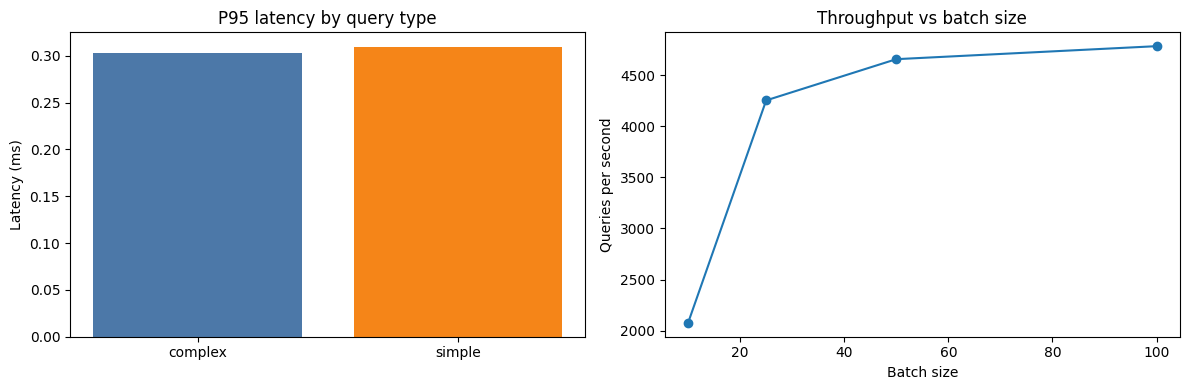

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(summary_df["query_type"], summary_df["p95_ms"], color=["#4C78A8", "#F58518"])
axes[0].set_title("P95 latency by query type")
axes[0].set_ylabel("Latency (ms)")

axes[1].plot(throughput_df["batch_size"], throughput_df["qps"], marker="o")
axes[1].set_title("Throughput vs batch size")
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("Queries per second")

plt.tight_layout()
plt.show()

### What the charts mean

- **Left (P95 latency by query type):** Compares how fast the slowest 5% of queries are for simple vs complex queries. Similar bars mean query wording has little impact on search speed.
- **Right (Throughput vs batch size):** Shows how many queries per second the system handles as batch size grows. A flattening curve means you’ve found the practical throughput limit.

## How to Explain the Results in a Demo

- If **p95** is low, most users get consistently fast responses.
- If **p99** is much higher than p95, tail latency needs attention.
- If throughput scales with batch size, the system handles parallel load efficiently.

This is the core story: **latency quality + throughput capacity**.